In [337]:
import haiku as hk
import optax

import jax 
from jax import numpy as jnp

import matplotlib.pyplot as plt

In [338]:
@hk.without_apply_rng
@hk.transform
def f(x):
    nn = hk.nets.MLP([50, 50, 1], activation=jnp.tanh)
    return nn(x)

params = f.init(jax.random.PRNGKey(42), jnp.ones((1, 1)))
net = f.apply

In [339]:
key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (1000,1))*5
y = 0.2*x + jnp.sin(x) + jnp.cos(x)* 0.5 * jnp.cos(x) + 0.1*jax.random.normal(key + 1, (1000,1))

In [340]:
prior_scale = 10.

In [371]:
optim = optax.adam(1e-4)
opt_state = optim.init(params)

def loss_fn(params):
    y_hat = net(params, x)
    return jnp.sum((y_hat - y)**2) + 1/prior_scale**2 * jax.tree_util.tree_reduce(lambda x, y: x + y, jax.tree_map(lambda x: jnp.sum(x**2), params))

@jax.jit
def step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optim.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state



In [372]:
for i in range(10000):
    loss, params, opt_state = step(params, opt_state, x, y)
    if i % 1000 == 0:
        print(loss)

12.062273
12.057026
12.045783
12.043653
12.031095
12.008586
11.997605
11.986196
11.975796
11.966363


In [373]:
import numpy as np
def flatten(params):
    flat_params, in_tree = jax.tree_util.tree_flatten(params)
    shapes = [p.shape for p in flat_params]
    lengths = [np.prod(p) for p in shapes]
    split_indices = np.cumsum(lengths)[:-1]
    flat_concat = jnp.concatenate([p.flatten() for p in flat_params])
    def unflatten(flat_params):
        params = jnp.split(flat_params, split_indices)
        params = [p.reshape(s) for p, s in zip(params, shapes)]
        return jax.tree_util.tree_unflatten(in_tree, params)
    return flat_concat, unflatten


In [374]:
flatten_param ,unflatten_fn = flatten(params)
def flatten_loss(params):
    return -loss_fn(unflatten_fn(params))

In [375]:
H = jax.hessian(flatten_loss)(flatten_param) 

In [378]:
# You need to add here something...
COV =  -H + 10* jnp.eye(flatten_param.shape[0])

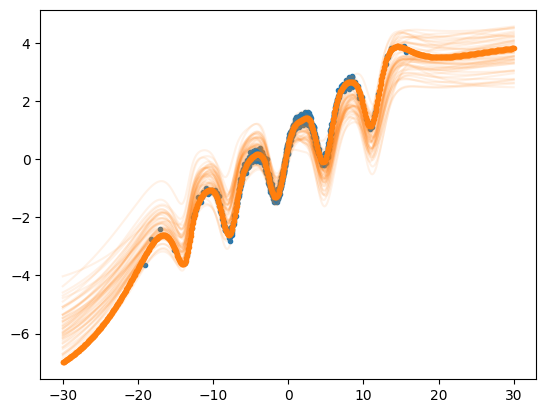

In [379]:
plt.plot(x, y, ".")

line = np.linspace(-30, 30, 1000).reshape(-1, 1)
plt.plot(line, net(params, line), ".")
for i in range(50):
    params2 = flatten_param + jnp.linalg.solve(COV, jax.random.normal(jax.random.PRNGKey(i), shape=flatten_param.shape))
    plt.plot(line.reshape(-1, 1), net(unflatten_fn(params2), line.reshape(-1, 1)), alpha=0.1, color="C1")

